# Classificazione dei prezzi delle case
### Progetto Finale – Introduzione alla Data Science AA 2025/2026

In questo notebook viene sviluppata una pipeline completa di data science applicata a un dataset di prezzi delle case. L'obiettivo è prevedere la classe di prezzo di una casa — suddivisa in 5 fasce da $0 a oltre $300.000 — a partire da informazioni geografiche, demografiche e strutturali delle aree di vendita.
Vengono implementati e confrontati quattro algoritmi di classificazione: minimizzazione del rischio empirico con loss quadratica e logistica, k-NN, alberi decisionali e Random Forest. La selezione del modello è condotta tramite cross-validation stratificata per garantire una buona capacità di generalizzazione sul test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Caricamento dati

In [2]:
# Apro il file csv sfruttando la libreria pandas
houses_data = pd.read_csv("houses_data.csv")

# Visualizzo le prime 5 righe
houses_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
0,-121.48,38.58,42.0,1823.0,566.0,761.0,503.0,1.2450,56605.775179,580889.416012,759695.004208,143043.151608,122257.998578,1
1,-118.16,33.96,24.0,1635.0,507.0,2480.0,481.0,2.4432,23275.681574,12833.107273,166591.203013,504538.443854,572564.270481,2
2,-116.41,33.74,17.0,4289.0,893.0,958.0,440.0,2.4659,109783.652563,172765.858404,133611.248886,636951.380308,704278.553944,2
3,-118.28,33.92,39.0,1274.0,282.0,975.0,277.0,1.5114,12482.064427,15080.299933,169527.675887,500778.155643,568764.984549,0
4,-118.20,33.96,41.0,1512.0,400.0,1690.0,367.0,3.0550,21094.938610,11018.189002,168689.069801,502131.598805,570150.638590,2


In [3]:
# Comando pandas per controllare che il caricamento sia avvenuto correttamente
print("Shape del dataset:", houses_data.shape)

# Comando pandas per controllare la struttura del dataset, i tipi di dato e la presenza di valori nulli
houses_data.info()

Shape del dataset: (10320, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 10320 non-null  float64
 1   latitude                  10320 non-null  float64
 2   housing_median_age        10320 non-null  float64
 3   total_rooms               10320 non-null  float64
 4   total_bedrooms            10222 non-null  float64
 5   population                10320 non-null  float64
 6   households                10320 non-null  float64
 7   median_income             10320 non-null  float64
 8   distance_to_coast         10320 non-null  float64
 9   distance_to_la            10320 non-null  float64
 10  distance_to_sandiego      10320 non-null  float64
 11  distance_to_sanjose       10320 non-null  float64
 12  distance_to_sanfrancisco  10320 non-null  float64
 13  median_house_value        1032

> _"Quali variabili sono categoriali e quali numeriche?"_

Tutte le variabili sono numeriche, quindi non è necessario alcun encoding. 
Il target median_house_value è però da considerare categoriale ordinale (valori 0–4 che rappresentano fasce di prezzo), motivo per cui il problema viene trattato come classificazione e non regressione.

In [4]:
# Comando pandas che mi genera le statistiche descrittive principali per le colonne numeriche, quindi per capire la distribuzione dei dati 
houses_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
count,10320.000000,10320.000000,10320.000000,10320.000000,10222.000000,10320.000000,10320.000000,10320.000000,10320.000000,1.032000e+04,1.032000e+04,10320.000000,10320.000000,10320.000000
mean,-119.574194,35.631556,28.659109,2649.005233,541.292115,1428.653876,502.031686,3.870005,39986.334263,2.694664e+05,3.982357e+05,349115.721531,386382.436629,2.006202
std,2.008333,2.137086,12.647918,2234.288240,434.323321,1161.103443,392.034757,1.882240,48666.189096,2.482746e+05,2.899353e+05,217399.018702,250646.207798,1.405746
min,-124.350000,32.560000,1.000000,6.000000,1.000000,3.000000,1.000000,0.499900,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313,0.000000
25%,-121.810000,33.930000,18.000000,1444.750000,295.000000,783.000000,279.000000,2.586500,8957.536866,3.195457e+04,1.594064e+05,111852.242379,116229.091976,1.000000
50%,-118.480000,34.250000,29.000000,2120.000000,435.000000,1167.000000,410.000000,3.550350,20373.551257,1.731238e+05,2.136897e+05,460412.398510,527470.345092,2.000000
75%,-118.000000,37.720000,37.000000,3150.000000,649.000000,1722.000000,606.000000,4.723900,48696.800918,5.276142e+05,7.062628e+05,517220.075858,584842.116382,3.000000
max,-114.310000,41.950000,52.000000,32054.000000,5290.000000,35682.000000,5050.000000,15.000100,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298,4.000000


In [5]:
# Separo la variabile target dalle features
X = houses_data.drop(columns=["median_house_value"])    # Tutte le colonne tranne median_house_value
y = houses_data["median_house_value"]                   # La colonna median_house_value

print("Shape di X:", X.shape)
print("Shape di y:", y.shape)


Shape di X: (10320, 13)
Shape di y: (10320,)


## 2. Visualizzazione dei dati

### 2.1 Dati mancanti

In [6]:
# Comando pandas e numpy per visualizzare quanti valori mancanti ci sono in ogni colonna 
houses_data.isnull().sum()

longitude                    0
latitude                     0
housing_median_age           0
total_rooms                  0
total_bedrooms              98
population                   0
households                   0
median_income                0
distance_to_coast            0
distance_to_la               0
distance_to_sandiego         0
distance_to_sanjose          0
distance_to_sanfrancisco     0
median_house_value           0
dtype: int64

> _"Ci sono valori mancanti? Quanti e su quali variabili? Come li puoi gestire?"_

I valori mancanti sono presenti solo sulla variabile total_bedrooms. Per gestirli si sceglie di applicare la mediana della colonna, preferita alla media perché più robusta alla presenza di outlier nei dati.

### 2.2 Classe bilanciate

In [7]:
# Comando pandas per verificare che le classi siano bilanciate
y.value_counts()

median_house_value
3    2112
1    2088
2    2072
4    2034
0    2014
Name: count, dtype: int64

<Axes: xlabel='median_house_value'>

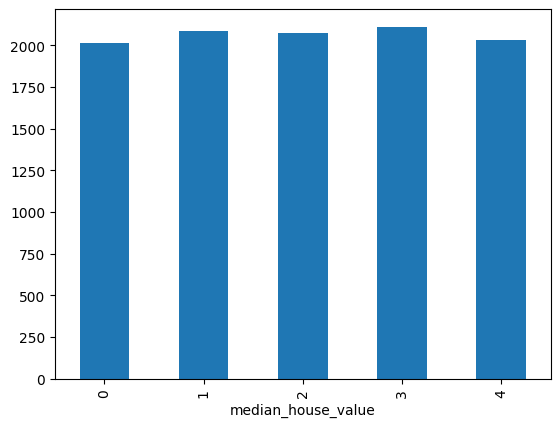

In [8]:
# Faccio il plot di un istogramma per mostrare il bilanciamento delle classi
y.value_counts().sort_index().plot(kind='bar')

Le 5 classi risultano sostanzialmente bilanciate. Non è quindi necessario adottare tecniche specifiche per gestire lo sbilanciamento delle classi.

### 2.3 Correlazione
Ipotesi: Mi aspetto che median_income sia la variabile più correlata al prezzo delle case, poiché il reddito di un'area è tipicamente un forte indicatore del valore immobiliare. Mi aspetto inoltre che total_rooms, total_bedrooms, households e population siano altamente correlate tra loro, in quanto descrivono tutte la densità abitativa di un'area.

In [9]:
# Comando pandas per trovare la matrice di correlazione
houses_data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
longitude,1.000000,-0.926031,-0.114574,0.056240,0.077455,0.108117,0.062041,-0.015004,0.012408,-0.893846,-0.959356,0.923300,0.954371,-0.026161
latitude,-0.926031,1.000000,0.021241,-0.048272,-0.075301,-0.116021,-0.077754,-0.080752,0.297101,0.941731,0.991669,-0.855404,-0.897521,-0.183050
housing_median_age,-0.114574,0.021241,1.000000,-0.366092,-0.328487,-0.303447,-0.313226,-0.115003,-0.223949,-0.020962,0.045640,-0.093149,-0.105845,0.077167
total_rooms,0.056240,-0.048272,-0.366092,1.000000,0.933320,0.853595,0.919446,0.192457,-0.000882,-0.029617,-0.050446,0.042343,0.043379,0.145598
total_bedrooms,0.077455,-0.075301,-0.328487,0.933320,1.000000,0.873360,0.978142,-0.006420,-0.021800,-0.062033,-0.076002,0.066488,0.067203,0.075369
population,0.108117,-0.116021,-0.303447,0.853595,0.873360,1.000000,0.903577,0.007413,-0.038781,-0.115478,-0.116675,0.086753,0.096053,0.013713
households,0.062041,-0.077754,-0.313226,0.919446,0.978142,0.903577,1.000000,0.014753,-0.061604,-0.066277,-0.075252,0.053360,0.055500,0.095207
median_income,-0.015004,-0.080752,-0.115003,0.192457,-0.006420,0.007413,0.014753,1.000000,-0.241643,-0.065954,-0.055792,-0.034445,-0.020542,0.625336
distance_to_coast,0.012408,0.297101,-0.223949,-0.000882,-0.021800,-0.038781,-0.061604,-0.241643,1.000000,0.189661,0.207754,-0.073872,-0.064099,-0.529245
distance_to_la,-0.893846,0.941731,-0.020962,-0.029617,-0.062033,-0.115478,-0.066277,-0.065954,0.189661,1.000000,0.951367,-0.794312,-0.848815,-0.166055


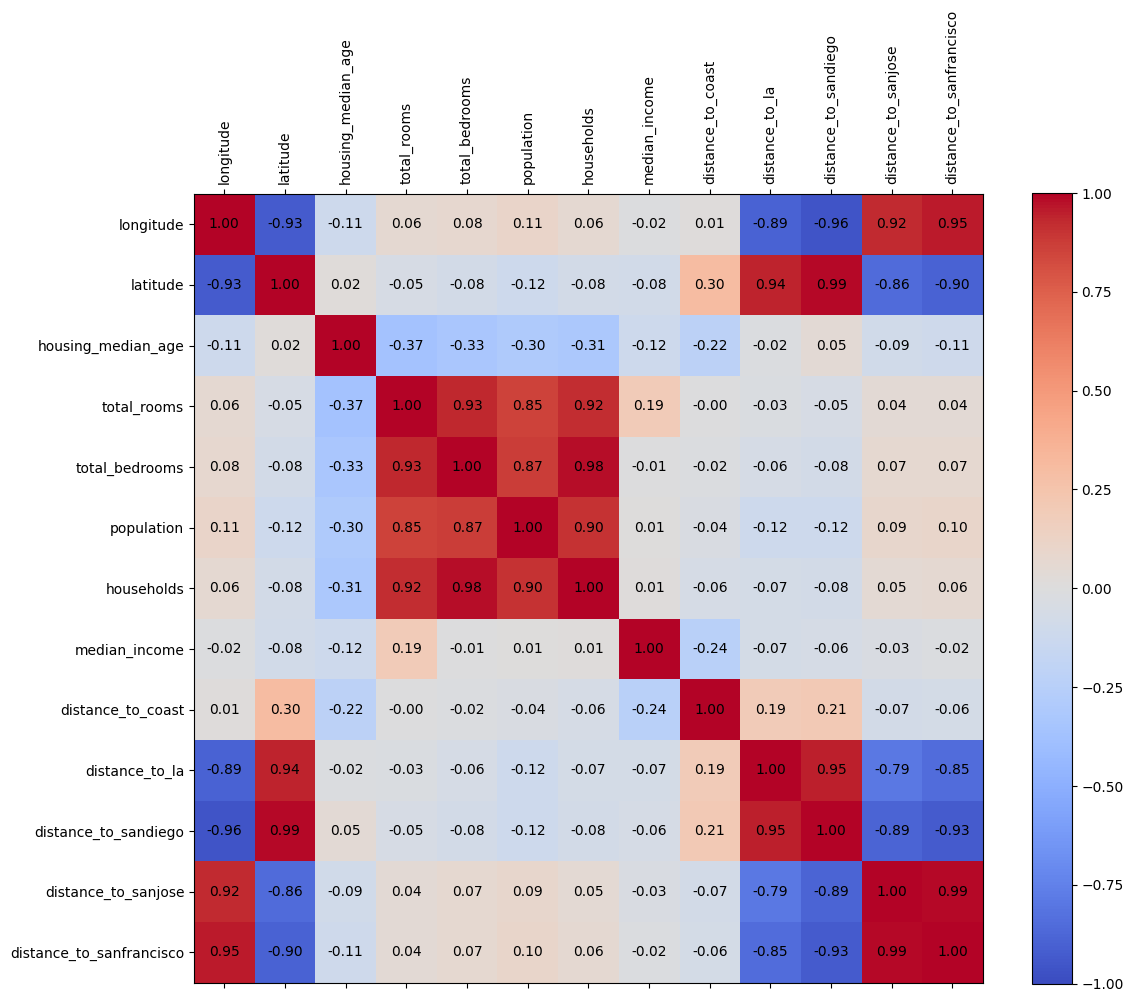

In [10]:
# Con Matplotlib e numpy creo la heatmap per vedere la correlazione tra le features
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax)

ticks = range(len(corr_matrix.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

# Mette i valori dentro ogni casella
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        valore = corr_matrix.iloc[i, j]
        
        ax.text(j, i, f"{valore:.2f}", 
                ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Verifica delle ipotesi:   
Come ipotizzato, median_income risulta la variabile più correlata al target (0.63), confermando che il reddito mediano di un'area è il principale predittore del valore delle case. Anche distance_to_coast mostra una correlazione significativa ma negativa (-0.53): le case vicine alla costa tendono ad avere prezzi più alti.
Le variabili total_rooms, total_bedrooms, households e population risultano fortemente correlate tra loro (valori tra 0.85 e 0.98), descrivendo tutte la stessa dimensione di densità abitativa dell'area. Infine, longitude e latitude sono altamente correlate con le distanze dalle città, coerentemente con la loro natura geografica.

## 3. Codifica della variabile target

Per problemi di classificazione multiclasse con _C_ classi, è necessario adattare gli algoritmi binari.  
Come descritto nell'Appendice A (Note del corso), dato un input $ x$, la predizione finale è ottenuta come:  
$$\hat{y}(x) = \arg\max_{c \in \{1,\dots,C\}} f_c(x)$$

- **Loss quadratica**: si adotta la codifica one-hot delle etichette $ e_y \in \mathbb{R}^C $ e si risolvono _C_ problemi di least squares separati, dove il c-esimo componente $f_c$ predice se l'etichetta è uguale a _c_ (Appendice A.2).
- **Regressione logistica**: si utilizza l'approccio one-vs-all (remark 6, Appendice A.3), addestrando _C_ classificatori logistici indipendenti, uno per classe.
- **k-NN e alberi decisionali**: gestiscono il multiclasse in modo alternativo, senza necessità di codifiche aggiuntive.

**Nota sul significato ordinale del target:** La variabile median_house_value non è una variabile categoriale pura, ma ordinale: le classi 0,1,2,3,4 rappresentano fasce di prezzo crescenti. Questo significa che un errore tra classi adiacenti (ad esempio 2 invece di 3) è concettualmente meno grave di un errore tra classi lontane (predire 0 invece di 4). Tuttavia, tutti gli algoritmi utilizzati trattano il problema come classificazione multiclasse standard, senza tenere conto di questa struttura ordinale. Questa limitazione potrà essere ossservata nella confusion matrix nelle sezioni successive, dove ci si aspetta che gli errori si concentrino prevalenemtne tra classi vicine.


## 4. Cross validation
Per selezionare i migliori iperparametri di ciascun modello senza fare overfitting sul training set, si utilizza la k-fold cross-validation stratificata.  
Il dataset viene suddiviso in _k_ fold di dimensione uguale, mantenendo in ciascuno la stessa proporzione di classi (stratificazione). Ad ogni iterazione, $ k-1 $ fold vengono usati per il training e il fold rimanente come validation set.  
L'errore finale è la media degli errori sul _k_ fold.  
Si sceglie $ k=5 $, un valore comunemente usato che bilancia bene bias e varianza della stima.

In [11]:
# Comando sklearn che mi assicura che ogni fold mantenga esattamente le stesse proporzioni percentuali delle classi osservate nel dataset di partenza 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Shuffle=True per mescolare i dati prima della suddivisione, evitando bias e random_state=42 
                                                                # per garantire riproducibilità dei risultati

## 5. Classificazione tramite minimizzazione del rischio empirico con loss quadratica
La classificazione con loss quadratica corrisponde a risolvere $ C=5$ problemi di least squares separati con codifica one-hot delle etichette (Appendice A.2). In sklearn si passa RidgeClassifier come argomento a OneVsRestClassifier.    
Il parametro alpha controlla la regolarizzazione.

### 5.1 Esegui il fit

In [12]:
# Pipeline per la gestione del preprocessing e del modello Ridge
# Previene il data leakage applicando le trasformazioni in sequenza
ridge_pipeline = Pipeline([
    # 1. Gestione NaN: sostituisce i valori mancanti con la mediana della colonna
    ("imputer", SimpleImputer(strategy="median")),
    # 2. Standardizzazione: porta i dati a media 0 e varianza 1 (fondamentale per i modelli lineari)
    ("scaler", StandardScaler()),
    # 3. Modello: Ridge Classifier esteso a problemi multiclasse (One-Vs-Rest)
    ("model", OneVsRestClassifier(RidgeClassifier()))
])

La gestione dei valori mancanti è inclusa nella pipeline tramite SimpleImputer(strategy="median") piuttosto che essere applicata prima della cross-validation.  
Questo evita il data leakage: se si imputasse la mediana sull'intero dataset prima della cross-validation, si userebbero informazioni provenienti anche dai fold di validation per calcolarla.  Includendola nella pipeline, sklearn ricalcola la mediana esclusivamente sui dati di training di ciascun fold e la applica poi al fold di validation. Inoltre, la mediana calcolata sul training set viene automaticamente riutilizzata al momento della predizione su nuovi dati, rendendo lo script finale corretto anche in presenza di valori mancanti nel test set.

In [13]:
# Definisco i parametri $\alpha$ da testare

ridge_param_grid = {
    "model__estimator__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
}

# Routine di grid search tramite cross validation del parametro ottimale

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

# Training su X e y 

ridge_grid.fit(X,y)

print("Migliori parametri RidgeClassifier:")
print(ridge_grid.best_params_)

Migliori parametri RidgeClassifier:
{'model__estimator__alpha': 0.1}


In [14]:
# Dizionario per visualizzare la mediana di ogni Feature di X
dict(zip(X.columns, ridge_grid.best_estimator_.named_steps['imputer'].statistics_))

{'longitude': -118.48,
 'latitude': 34.25,
 'housing_median_age': 29.0,
 'total_rooms': 2120.0,
 'total_bedrooms': 435.0,
 'population': 1167.0,
 'households': 410.0,
 'median_income': 3.55035,
 'distance_to_coast': 20373.55125721665,
 'distance_to_la': 173123.808045815,
 'distance_to_sandiego': 213689.7066499945,
 'distance_to_sanjose': 460412.398510286,
 'distance_to_sanfrancisco': 527470.345092147}

### 5.2 Interpretare i coefficienti ottenuti

In [15]:
for i, est in enumerate(ridge_grid.best_estimator_.named_steps['model'].estimators_):
    print(f"Classe {i}:", est.coef_)

Classe 0: [ 0.21674604 -0.82567537  0.06714805  0.02507707 -0.21203955  0.05355601
  0.09892215 -0.20640306  0.36842438  0.19484684  1.16305115 -0.23116968
  0.51180764]
Classe 1: [ 0.32406148  1.34034532 -0.04974643 -0.00912505  0.08088575  0.21838491
 -0.28665758 -0.1696568  -0.16863317  0.17896052 -1.37000791  0.07626642
 -0.3014135 ]
Classe 2: [-0.03737349  0.74056189 -0.08315244 -0.05146984  0.06316332  0.11446785
 -0.14228424 -0.07946996 -0.17243374 -0.0656176  -0.86111189  0.04666823
 -0.16656871]
Classe 3: [-0.24478694 -0.35091355 -0.03715418  0.04997227 -0.05556245 -0.11978938
  0.16293801  0.03269884 -0.08382666 -0.12953558  0.24451595 -0.23705999
  0.25804769]
Classe 4: [-0.25864709 -0.90431829  0.102905   -0.01445445  0.12355293 -0.26661939
  0.16708166  0.42283098  0.05646919 -0.17865418  0.8235527   0.34529502
 -0.30187311]


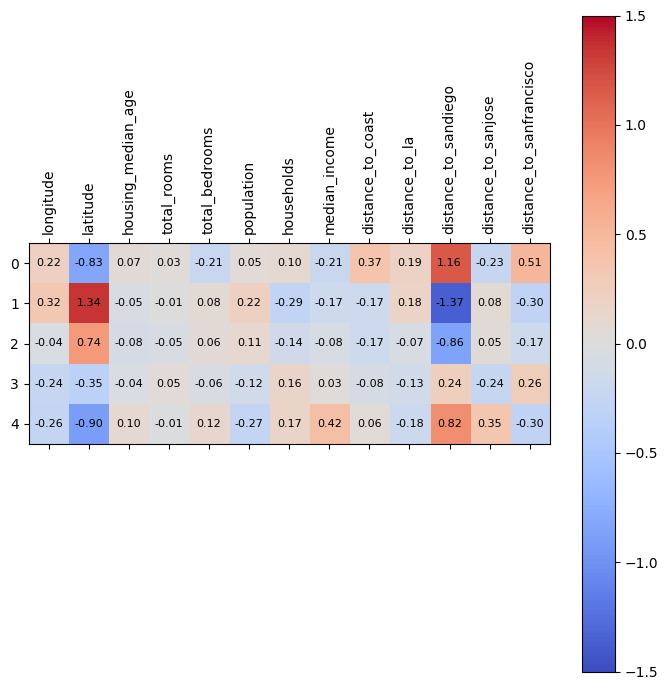

In [16]:
# np.vstack invece impila verticalmente i vettori di coefficienti di ciascun classificatore, costruendo correttamente una matrice 5×13
coef_matrix = np.vstack([est.coef_ for est in ridge_grid.best_estimator_.named_steps['model'].estimators_])

# Heatmap per vedere la correlazione tra coefficienti e feature di X
fig, ax = plt.subplots(figsize=(7, 7))
cax = ax.matshow(coef_matrix, cmap='coolwarm', vmin=-1.5, vmax=1.5)

fig.colorbar(cax)

ax.set_xticks(range(len(X.columns)))
ax.set_yticks(range(5))
ax.set_xticklabels(X.columns, rotation=90)
ax.set_yticklabels([0, 1, 2, 3, 4])

for i in range(5):
    for j in range(len(X.columns)):
        valore = coef_matrix[i, j]
        ax.text(j, i, f"{valore:.2f}",
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

I coefficienti del modello Ridge permettono di capire quali feature influenzano maggiormente la predizione di ciascuna classe.

- Classe 0 (case economiche): il coefficiente più alto è distance_to_coast (1.16), coerente con l'analisi delle correlazioni, le case lontane dalla costa tendono ad avere prezzi più bassi.
- Classe 1: latitude ha coefficiente positiva (1.34) mentre median_income è negativa (-1.37), quindi aree con reddito basso e posizione più a nord tendono ad appartenere a questa fascia.
- Classe 2: latitude è ancora positiva (0.74) mentre distance_to_sandiego è negativa (-0.86), zone nella fascia centrale della California.
- Classe 3: i coefficienti sono generalmente più bassi, suggerendo che questa classe è più difficile da separare dalle adiacenti.
- Classe 4 (case costose): median_income ha il coefficiente più alto (0.82), confermando che il reddito è il principale predittore delle case di lusso, coerentemente con la correlazione di 0.63 trovata in precedenza.

### 5.3 Valutazione delle prestazioni

In [17]:
print("Miglior accuracy media in CV del parametro:", ridge_grid.best_score_, ridge_grid.best_params_)

Miglior accuracy media in CV del parametro: 0.4919573643410852 {'model__estimator__alpha': 0.1}


mean=0.4917636, std=0.00725775, params={'model__estimator__alpha': 0.001}
mean=0.4917636, std=0.00725775, params={'model__estimator__alpha': 0.01}
mean=0.4919574, std=0.00722923, params={'model__estimator__alpha': 0.1}
mean=0.4915698, std=0.00738980, params={'model__estimator__alpha': 0.5}
mean=0.4906977, std=0.00774224, params={'model__estimator__alpha': 1.0}
mean=0.4904070, std=0.00988847, params={'model__estimator__alpha': 10.0}
mean=0.4789729, std=0.00696462, params={'model__estimator__alpha': 100.0}


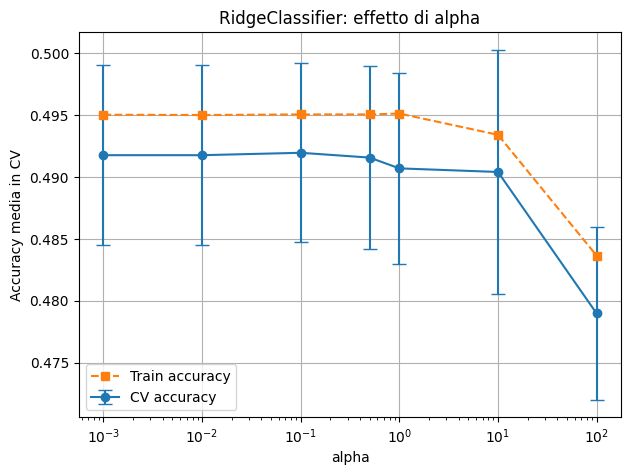

In [18]:
ridge_results = ridge_grid.cv_results_

for mean, std, params in zip(
    ridge_results["mean_test_score"],
    ridge_results["std_test_score"],
    ridge_results["params"]
):
    print(f"mean={mean:.7f}, std={std:.8f}, params={params}")

alphas = ridge_param_grid["model__estimator__alpha"]
plt.figure(figsize=(7, 5))
# errorbar mi mostra la CV accuracy con le barre di errore
plt.errorbar(alphas, ridge_results["mean_test_score"], yerr=ridge_results["std_test_score"], marker="o", capsize=5,  label="CV accuracy")
# plot perchè mi serve solo come riferimento visivo per capire se c'è overfitting (gap grande tra train e CV) o underfitting (entrambe basse)
plt.plot(alphas, ridge_results["mean_train_score"], marker="s", linestyle="--", label="Train accuracy")
plt.xscale("log")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Accuracy media in CV")
plt.title("RidgeClassifier: effetto di alpha")
plt.legend()
plt.grid(True)
plt.show()

Il grafico mostra l'accuracy media in cross-validation al variare del parametro di regolarizzazione alpha.  
Per valori bassi di alpha (da 0.001 a 0.5) l'accuracy è stabile intorno a 0.492, indicando che il modello è poco sensibile alla regolarizzazione in questo range.  
Per valori più alti (10 e 100) le prestazioni calano progressivamente, suggerendo che una regolarizzazione eccessiva penalizza il modello riducendone la capacità predittiva
Il gap piccolo tra train accuracy e CV accuracy indica che il modello non soffre di overfitting, ma di underfitting: il modello lineare non cattura a sufficienza la struttura del problema.

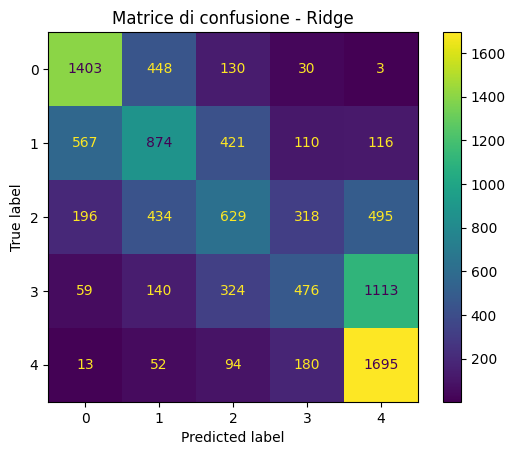

Accuracy: 0.4919573643410853


In [19]:
# Confusion matrix per valutare le prestazioni del modello 
y_pred = cross_val_predict(ridge_grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)
disp.plot()
plt.title("Matrice di confusione - Ridge")
plt.show()

# Accuracy calcolata per il multiclasse 
print("Accuracy:", accuracy_score(y, y_pred))

Gli errori si concentrano principalmente tra classi adiacenti (esempio:  classe 1 confusa con 0 e 2). Questo è coerente con quanto detto nella sezione 3: sbagliare di una fascia di prezzo vicina è "più comprensibile" che sbagliare tra le classi estreme. Avendo pochi errori su classi estreme conferma che il modello raramente confonde case economiche con case di lusso.

## 6. Classificazione tramite minimizzazione del rischio empirico con loss logistica

La classificazione con loss logistica corrisponde alla regressione logistica multiclasse con funzione softmax (Appendice A.3). A differenza della loss quadratica, non è necessario usare OneVsRestClassifier poiché LogisticRegression di sklearn gestisce il multiclasse nativamente.  
Il parametro C controlla la regolarizzazione — valori alti di C corrispondono a poca regolarizzazione, valori bassi a molta.

### 6.1 Esegui il fit

In [20]:
# Pipeline per la gestione del preprocessing e del modello LogisticRegression
# Previene il data leakage applicando le trasformazioni in sequenza
logistic_pipeline = Pipeline([
    # 1. Gestione NaN: sostituisce i valori mancanti con la mediana della colonna
    ("imputer", SimpleImputer(strategy="median")),
    # 2. Standardizzazione: porta i dati a media 0 e varianza 1 (fondamentale per i modelli lineari)
    ("scaler", StandardScaler()),
    # 3. Modello: Logistic Regression
    ("model", LogisticRegression(max_iter=5000))
])

In [21]:
# Definisco i parametri C da testare

logistic_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
}

# Routine di grid search tramite cross validation del parametro ottimale

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

# Training su X e y 

logistic_grid.fit(X,y)

print("Migliori parametri LogisticRegression:")
print(logistic_grid.best_params_)

Migliori parametri LogisticRegression:
{'model__C': 1000.0}


In [22]:
# Dizionario per visualizzare la mediana di ogni Feature di X
dict(zip(X.columns, logistic_grid.best_estimator_.named_steps['imputer'].statistics_))

{'longitude': -118.48,
 'latitude': 34.25,
 'housing_median_age': 29.0,
 'total_rooms': 2120.0,
 'total_bedrooms': 435.0,
 'population': 1167.0,
 'households': 410.0,
 'median_income': 3.55035,
 'distance_to_coast': 20373.55125721665,
 'distance_to_la': 173123.808045815,
 'distance_to_sandiego': 213689.7066499945,
 'distance_to_sanjose': 460412.398510286,
 'distance_to_sanfrancisco': 527470.345092147}

### 6.2 Analisi dell’effetto del parametro di regolarizzazione

In [23]:
print("Miglior accuracy media in CV del parametro:", logistic_grid.best_score_, logistic_grid.best_params_)

Miglior accuracy media in CV del parametro: 0.5645348837209303 {'model__C': 1000.0}


mean=0.4951550, std=0.00569978, params={'model__C': 0.001}
mean=0.5323643, std=0.00891999, params={'model__C': 0.01}
mean=0.5549419, std=0.01206619, params={'model__C': 0.1}
mean=0.5625969, std=0.01108808, params={'model__C': 1.0}
mean=0.5633721, std=0.01002989, params={'model__C': 10.0}
mean=0.5642442, std=0.00934764, params={'model__C': 100.0}
mean=0.5645349, std=0.00938173, params={'model__C': 1000.0}
mean=0.5643411, std=0.00797522, params={'model__C': 10000.0}


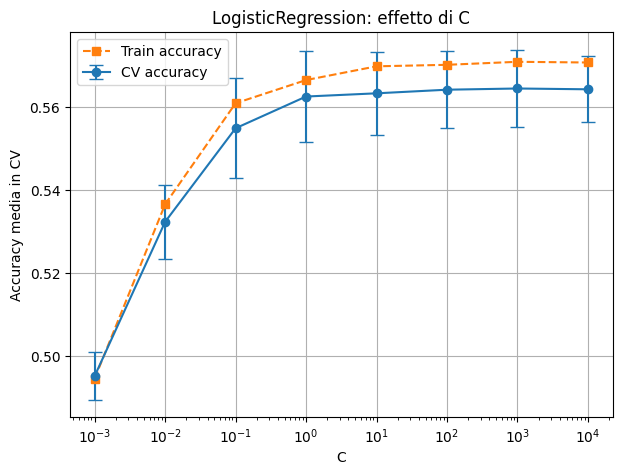

In [24]:
logistic_results = logistic_grid.cv_results_

for mean, std, params in zip(
    logistic_results["mean_test_score"],
    logistic_results["std_test_score"],
    logistic_results["params"]
):
    print(f"mean={mean:.7f}, std={std:.8f}, params={params}")

C = logistic_param_grid["model__C"]
plt.figure(figsize=(7, 5))
plt.errorbar(C, logistic_results["mean_test_score"], yerr=logistic_results["std_test_score"], marker="o", capsize=5, label="CV accuracy")
plt.plot(C, logistic_results["mean_train_score"], marker="s", linestyle="--", label="Train accuracy")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy media in CV")
plt.title("LogisticRegression: effetto di C")
plt.legend()
plt.grid(True)
plt.show()

Il grafico mostra l'accuracy media in cross-validation al variare del parametro di regolarizzazione C.    
Per C piccolo (0.001) l'accuracy è bassa (0.49): troppa regolarizzazione penalizza il modello.     
L'accuracy cresce rapidamente fino a C=1, da cui in poi si stabilizza intorno a 0.56.  

Il gap ridotto tra train accuracy e CV accuracy, stabile da C=1 in poi, indica che anche qui il modello soffre principalmente di underfitting piuttosto che overfitting.

### 6.3 Quali classi sono più difficili da predire?

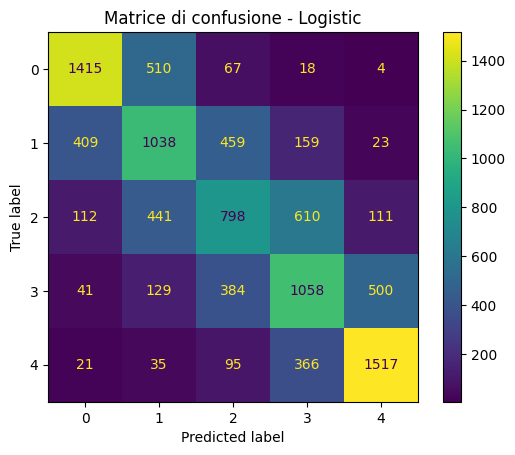

Accuracy: 0.5645348837209302


In [25]:
# Confusion matrix per valutare le prestazioni del modello 
y_pred = cross_val_predict(logistic_grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)
disp.plot()
plt.title("Matrice di confusione - Logistic")
plt.show()

# Accuracy calcolata per il multiclasse 
print("Accuracy:", accuracy_score(y, y_pred))

Analizzando la matrice di confusione, le classi più difficili da predire sono la 2 e la 3, che ottengono i valori più bassi sulla diagonale (798 e 1058). Queste sono le classi centrali, che possono essere confuse in entrambe le direzioni con le classi adiacenti. Inoltre corrispondono a fasce di prezzo intermedie, associate a zone con caratteristiche geografiche e reddituali più miste. Al contrario, le classi estreme 0 e 4 vengono riconosciute meglio (1415 e 1517), poiché corrispondono a profili più netti e distinguibili.

## 7. k-NN

Il k-Nearest Neighbors (k-NN) è un metodo locale non lineare (Sezione 5.2): per ogni nuovo input, la predizione è ottenuta come voto di maggioranza tra le etichette dei k esempi più vicini nel training set.  
Il parametro k controlla il compromesso tra bias e varianza: per k=1 il modello è molto flessibile e tende all'overfitting, per k grande diventa più stabile ma meno adattivo. k-NN gestisce il multiclasse nativamente, senza necessità di codifiche aggiuntive.

### 7.1 esegui il fit

In [26]:
# Pipeline per la gestione del preprocessing e del modello kNN
# Previene il data leakage applicando le trasformazioni in sequenza
knn_pipeline = Pipeline([
    # 1. Gestione NaN: sostituisce i valori mancanti con la mediana della colonna
    ("imputer", SimpleImputer(strategy="median")),
    # 2. Standardizzazione: porta i dati a media 0 e varianza 1 (fondamentale per i modelli lineari)
    ("scaler", StandardScaler()),
    # 3. Modello: k-Nearest Neighbors
    ("model", KNeighborsClassifier())
])

In [27]:
# Definisco i parametri C da testare

knn_param_grid = {
    "model__n_neighbors": [1, 3, 5, 10, 15, 20, 30, 50]
}

# Routine di grid search tramite cross validation del parametro ottimale

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

# Training su X e y 

knn_grid.fit(X,y)

print("Migliori parametri k-Nearest Neighbors:")
print(knn_grid.best_params_)

Migliori parametri k-Nearest Neighbors:
{'model__n_neighbors': 20}


In [28]:
# Dizionario per visualizzare la mediana di ogni Feature di X
dict(zip(X.columns, knn_grid.best_estimator_.named_steps['imputer'].statistics_))

{'longitude': -118.48,
 'latitude': 34.25,
 'housing_median_age': 29.0,
 'total_rooms': 2120.0,
 'total_bedrooms': 435.0,
 'population': 1167.0,
 'households': 410.0,
 'median_income': 3.55035,
 'distance_to_coast': 20373.55125721665,
 'distance_to_la': 173123.808045815,
 'distance_to_sandiego': 213689.7066499945,
 'distance_to_sanjose': 460412.398510286,
 'distance_to_sanfrancisco': 527470.345092147}

### 7.2 Studia l’errore al variare di k valutando se esiste un valore ottimale

In [29]:
print("Miglior accuracy media in CV del parametro:", knn_grid.best_score_, knn_grid.best_params_)

Miglior accuracy media in CV del parametro: 0.5708333333333334 {'model__n_neighbors': 20}


mean=0.5365310, std=0.00740883, params={'model__n_neighbors': 1}
mean=0.5356589, std=0.00888941, params={'model__n_neighbors': 3}
mean=0.5598837, std=0.01258422, params={'model__n_neighbors': 5}
mean=0.5684109, std=0.00935667, params={'model__n_neighbors': 10}
mean=0.5699612, std=0.01178272, params={'model__n_neighbors': 15}
mean=0.5708333, std=0.01000646, params={'model__n_neighbors': 20}
mean=0.5627907, std=0.01193710, params={'model__n_neighbors': 30}
mean=0.5515504, std=0.01080589, params={'model__n_neighbors': 50}


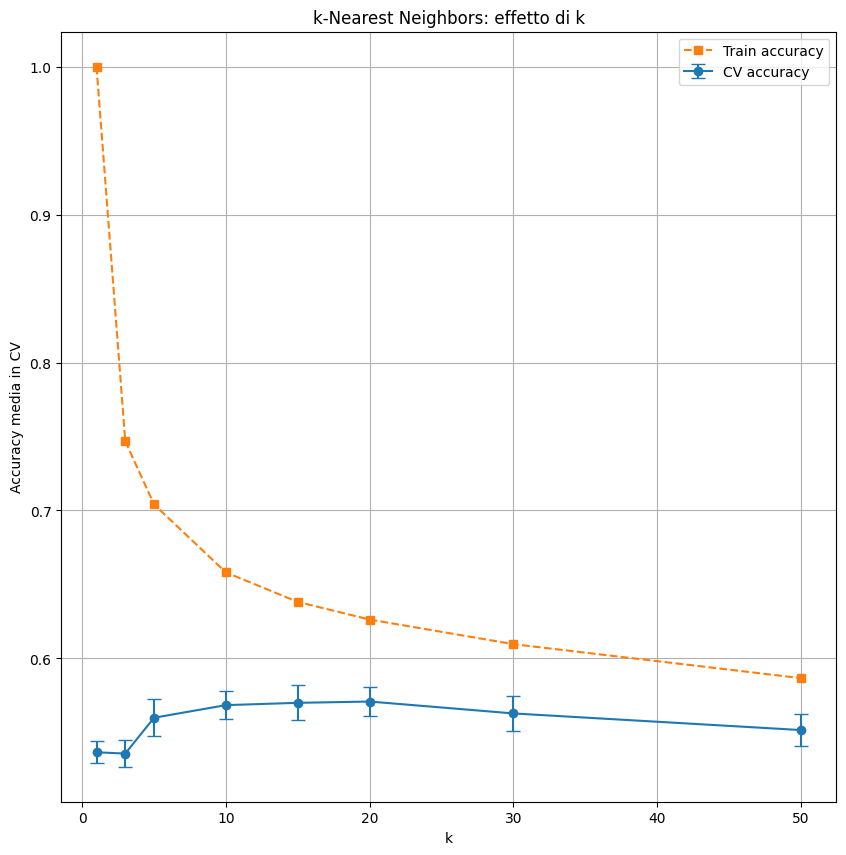

In [30]:
knn_results = knn_grid.cv_results_

for mean, std, params in zip(
    knn_results["mean_test_score"],
    knn_results["std_test_score"],
    knn_results["params"]
):
    print(f"mean={mean:.7f}, std={std:.8f}, params={params}")

k = knn_param_grid["model__n_neighbors"]
plt.figure(figsize=(10, 10))
plt.errorbar(k, knn_results["mean_test_score"], yerr=knn_results["std_test_score"], marker="o", capsize=5, label="CV accuracy")
plt.plot(k, knn_results["mean_train_score"], marker="s", linestyle="--", label="Train accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy media in CV")
plt.title("k-Nearest Neighbors: effetto di k")
plt.legend()
plt.grid(True)
plt.show()

Per k=1 la train accuracy raggiunge 1.0, ma la CV accuracy è bassa, questo significa che ho overfitting.  
All'aumentare di k il gap si riduce progressivamente: la train accuracy scende e la CV accuracy cresce, raggiungendo il massimo intorno a k=20.   
Per k molto grandi (k=50) entrambe le curve scendono leggermente, indicando che il modello diventa troppo rigido e perde la capacità di adattarsi alla struttura locale dei dati.

### 7.3 Commenta complessità e accuratezza

Complessità:
- la fase di training è O(1) poiché il modello si limita a memorizzare i dati
- la fase di predizione richiede O(n·d) operazioni per ogni nuovo esempio, dove n è il numero di campioni e d il numero di feature. Questo perché per ogni predizione è necessario calcolare la distanza da tutti i punti del training set. Al contrario dei modelli lineari, che una volta addestrati predicono in tempo costante, kNN diventa, quindi, computazionalmente oneroso su dataset molto grandi.

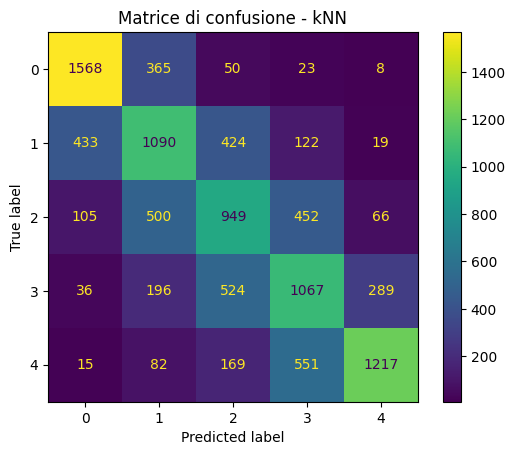

Accuracy: 0.5708333333333333


In [31]:
# Confusion matrix per valutare le prestazioni del modello 
y_pred = cross_val_predict(knn_grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)
disp.plot()
plt.title("Matrice di confusione - kNN")
plt.show()

# Accuracy calcolata per il multiclasse 
print("Accuracy:", accuracy_score(y, y_pred))

In termini di accuratezza, il modello ottiene 0.571 in cross-validation, confermando che la struttura del problema presenta componenti non lineari che un metodo locale riesce a catturare meglio di un modello lineare. Il pattern degli errori rimane lo stesso osservato in precedenza: le classi centrali 2 e 3 sono le più difficili da predire, mentre le classi estreme 0 e 4 vengono riconosciute con maggiore precisione.

## 8. Alberi decisionali
L'albero decisionale è un metodo non lineare basato sulla suddivisione ricorsiva dello spazio delle feature (Sezione 5.5): a partire dall'intero dataset, ad ogni nodo viene scelto il threshold s che minimizza l'errore empirico nelle due regioni risultanti. Il processo viene ripetuto ricorsivamente fino a raggiungere le foglie, dove viene assegnata la predizione costante ottimale. Il parametro principale è la profondità massima: alberi poco profondi corrispondono a partizioni grossolane e modelli semplici (underfitting), alberi molto profondi a partizioni fini e modelli più flessibili che rischiano l'overfitting. Come kNN, l'albero decisionale gestisce il multiclasse nativamente senza necessità di codifiche aggiuntive.

### 8.1 Analizza l’effetto dei parametri dell’albero (ad esempio profondità massima, numero minimo di campioni per foglia) sulle prestazioni del modello.

In [32]:
# Pipeline per la gestione del preprocessing e del modello DecisionTree
# Previene il data leakage applicando le trasformazioni in sequenza
tree_pipeline = Pipeline([
    # 1. Gestione NaN: sostituisce i valori mancanti con la mediana della colonna
    ("imputer", SimpleImputer(strategy="median")),
    # 2. Standardizzazione: porta i dati a media 0 e varianza 1 (fondamentale per i modelli lineari)
    ("scaler", StandardScaler()),
    # 3. Modello: Decision Tree
    ("model", DecisionTreeClassifier())
])

In [33]:
tree_param_grid = {
    "model__max_depth": [2, 3, 5, 10, 15, 20, None],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

tree_grid.fit(X, y)

print("Migliori parametri DecisionTreeClassifier:")
print(tree_grid.best_params_)
print("Miglior accuracy media in CV:", tree_grid.best_score_)


Migliori parametri DecisionTreeClassifier:
{'model__max_depth': 15, 'model__min_samples_leaf': 10}
Miglior accuracy media in CV: 0.6038759689922479


In [34]:
# Dizionario per visualizzare la mediana di ogni Feature di X
dict(zip(X.columns, tree_grid.best_estimator_.named_steps['imputer'].statistics_))

{'longitude': -118.48,
 'latitude': 34.25,
 'housing_median_age': 29.0,
 'total_rooms': 2120.0,
 'total_bedrooms': 435.0,
 'population': 1167.0,
 'households': 410.0,
 'median_income': 3.55035,
 'distance_to_coast': 20373.55125721665,
 'distance_to_la': 173123.808045815,
 'distance_to_sandiego': 213689.7066499945,
 'distance_to_sanjose': 460412.398510286,
 'distance_to_sanfrancisco': 527470.345092147}

In [35]:
print("Miglior accuracy media in CV del parametro:", tree_grid.best_score_, tree_grid.best_params_)

Miglior accuracy media in CV del parametro: 0.6038759689922479 {'model__max_depth': 15, 'model__min_samples_leaf': 10}


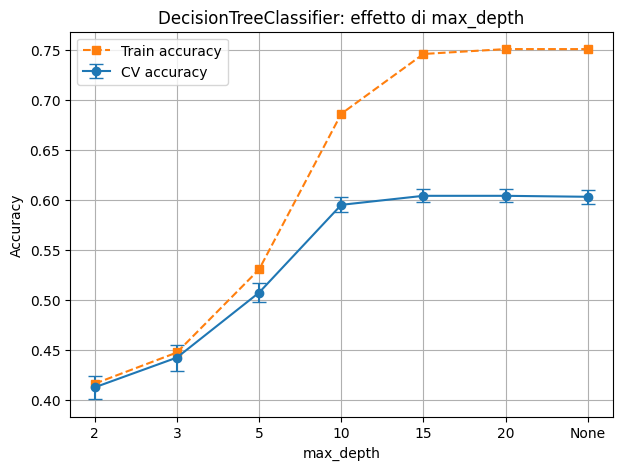

In [36]:
tree_results = tree_grid.cv_results_

depths = tree_param_grid["model__max_depth"]
depth_labels = [str(d) for d in depths]

means_test = []
means_train = []
stds = []

for depth in depths:
    for p, mean_test, mean_train, std in zip(
        tree_results["params"],
        tree_results["mean_test_score"],
        tree_results["mean_train_score"],
        tree_results["std_test_score"],
    ):
        if p["model__max_depth"] == depth and p["model__min_samples_leaf"] == 10:
            means_test.append(mean_test)
            means_train.append(mean_train)
            stds.append(std)
            break

plt.figure(figsize=(7, 5))
plt.errorbar(depth_labels, means_test, yerr=stds, marker="o", capsize=5, label="CV accuracy")
plt.plot(depth_labels, means_train, marker="s", linestyle="--", label="Train accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("DecisionTreeClassifier: effetto di max_depth")
plt.legend()
plt.grid(True)
plt.show()

- Per profondità piccole (2,3):
    - Train Accuracy è circa uguale a CV accuracy 
    - Questo significa che il modello è troppo semplice e l'albero non riesce a catturare la struttura dei dati

- Per profondità uguale a 5:  
    - Le due curce inziano a divergere
    - Il modello comincia ad adattarsi meglio ai dati di training

- Per pronfondità uguale a 10 e 15:
    -  La divergenza aumenta, Train Accuracy sale molto mentre CV Accuracy si stabilizza
    -  Qua c'è overfitting, il modello memorizza i dati di training, ma non li generalizza 

- Per pronfondità uguale a 20 e None:
    - Sia Train Accuracy che CV Accuracy sono stabili
    - Aggiungere profondità non migliora più nulla, il modello ha già memorizzato tutto quello che può

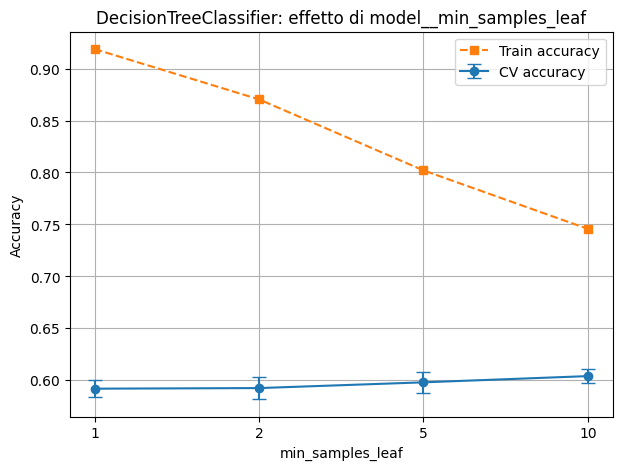

In [37]:
tree_results = tree_grid.cv_results_

depths = tree_param_grid["model__min_samples_leaf"]
depth_labels = [str(d) for d in depths]

means_test = []
means_train = []
stds = []

for depth in depths:
    for p, mean_test, mean_train, std in zip(
        tree_results["params"],
        tree_results["mean_test_score"],
        tree_results["mean_train_score"],
        tree_results["std_test_score"],
    ):
        if p["model__min_samples_leaf"] == depth and p["model__max_depth"] == 15:
            means_test.append(mean_test)
            means_train.append(mean_train)
            stds.append(std)
            break

plt.figure(figsize=(7, 5))
plt.errorbar(depth_labels, means_test, yerr=stds, marker="o", capsize=5, label="CV accuracy")
plt.plot(depth_labels, means_train, marker="s", linestyle="--", label="Train accuracy")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("DecisionTreeClassifier: effetto di model__min_samples_leaf")
plt.legend()
plt.grid(True)
plt.show()

La CV Accuracy è quasi piatta al variare di min_samples_leaf, mentre la Train Accuracy scende molto. Questo significa che il parametro influenza principalmente il grado di overfitting, ma non cambia la capacità di generalizzazione del modello ottimale.

### 8.2 Quali variabili risultano più importanti secondo il modello? I risultati sono coerenti con l’analisi delle correlazioni?

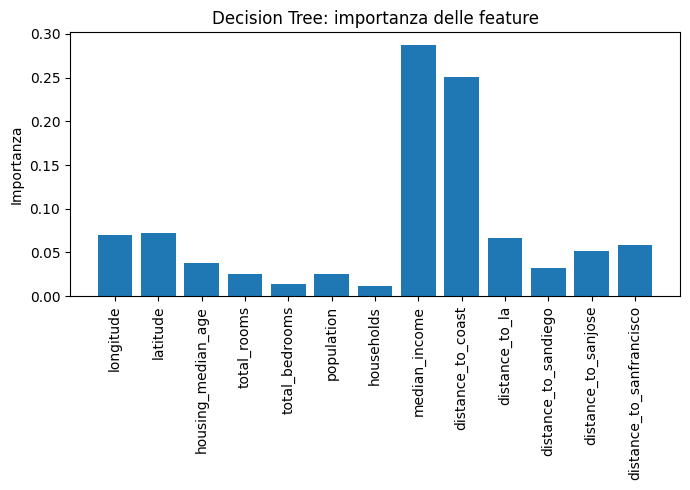

In [38]:
best_tree = tree_grid.best_estimator_.named_steps["model"]

plt.figure(figsize=(7, 5))
plt.bar(X.columns, best_tree.feature_importances_)
plt.xticks(rotation=90)
plt.ylabel("Importanza")
plt.title("Decision Tree: importanza delle feature")
plt.tight_layout()
plt.show()

Le feature più importanti secondo l'albero decisionale sono median_income (0.29) e distance_to_coast (0.25), che insieme spiegano oltre il 50% delle decisioni dell'albero.   
Questo risultato è pienamente coerente con l'analisi delle correlazioni della sezione 2, dove queste stesse variabili mostravano le correlazioni più alte con il target (0.63 e -0.53).  
Le variabili geografiche come longitude e latitude hanno un'importanza moderata (~0.07), mentre le variabili di dimensione dell'area (total_rooms, total_bedrooms, population, households) risultano poco rilevanti, confermando che la dimensione dell'abitazione conta meno della posizione e del reddito nel determinare la fascia di prezzo.

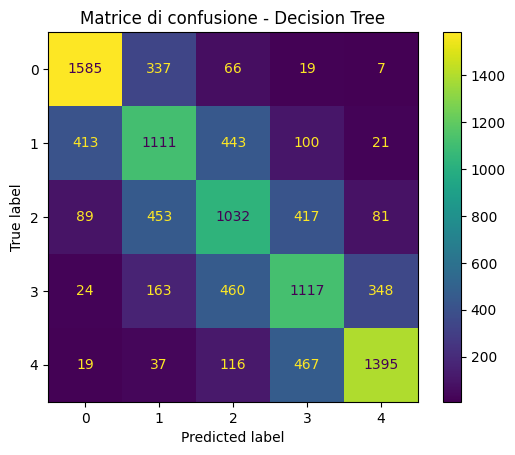

Accuracy: 0.6046511627906976


In [39]:
# Confusion matrix per valutare le prestazioni del modello 
y_pred = cross_val_predict(tree_grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)
disp.plot()
plt.title("Matrice di confusione - Decision Tree")
plt.show()

# Accuracy calcolata per il multiclasse 
print("Accuracy:", accuracy_score(y, y_pred))

Gli errori si concentrano tra classi adiacenti: la classe 2 è la più difficile da predire (1032 sulla diagonale), confusa soprattutto con la classe 1 (453) e la classe 3 (418).

## 9. (Opzionale) Random Forest

L'algoritmo Random Forest estende l'idea dell'albero decisionale della sezione 8: invece di addestrare un singolo albero, ne vengono addestrati n_estimators alberi, ciascuno su un sottocampione casuale del training set e con un sottoinsieme casuale di feature ad ogni split. Poiché ogni albero vede dati e feature diversi, commette errori diversi
dagli altri.  
La predizione finale è ottenuta per voto di maggioranza: gli errori dei singoli alberi tendono a cancellarsi, rendendo il modello complessivo più robusto e meno soggetto all'overfitting rispetto a un singolo albero profondo. 

Il multiclasse è gestito nativamente, come per gli alberi decisionali.

I parametri principali da ottimizzare sono n_estimators (numero di alberi) e max_depth (profondità massima di ogni albero).

In [40]:
# Pipeline per la gestione del preprocessing e del modello RandomForest
# Previene il data leakage applicando le trasformazioni in sequenza
forest_pipeline = Pipeline([
    # 1. Gestione NaN: sostituisce i valori mancanti con la mediana della colonna
    ("imputer", SimpleImputer(strategy="median")),
    # 2. Standardizzazione: porta i dati a media 0 e varianza 1 (fondamentale per i modelli lineari)
    ("scaler", StandardScaler()),
    # 3. Modello: Random Forest
    # random_state controlla la costruzione interna degli alberi altrimenti cambia ogni run
    ("model", RandomForestClassifier(random_state=42))
])

In [41]:
forest_param_grid = {
    "model__n_estimators": [50, 100, 150,200],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_leaf": [1, 5, 10]
}

forest_grid = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=forest_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

forest_grid.fit(X, y)

print("Migliori parametri RandomForestClassifier:")
print(forest_grid.best_params_)
print("Miglior accuracy media in CV:", forest_grid.best_score_)

Migliori parametri RandomForestClassifier:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 150}
Miglior accuracy media in CV: 0.6874031007751938


In [42]:
# Dizionario per visualizzare la mediana di ogni Feature di X
dict(zip(X.columns, forest_grid.best_estimator_.named_steps['imputer'].statistics_))

{'longitude': -118.48,
 'latitude': 34.25,
 'housing_median_age': 29.0,
 'total_rooms': 2120.0,
 'total_bedrooms': 435.0,
 'population': 1167.0,
 'households': 410.0,
 'median_income': 3.55035,
 'distance_to_coast': 20373.55125721665,
 'distance_to_la': 173123.808045815,
 'distance_to_sandiego': 213689.7066499945,
 'distance_to_sanjose': 460412.398510286,
 'distance_to_sanfrancisco': 527470.345092147}

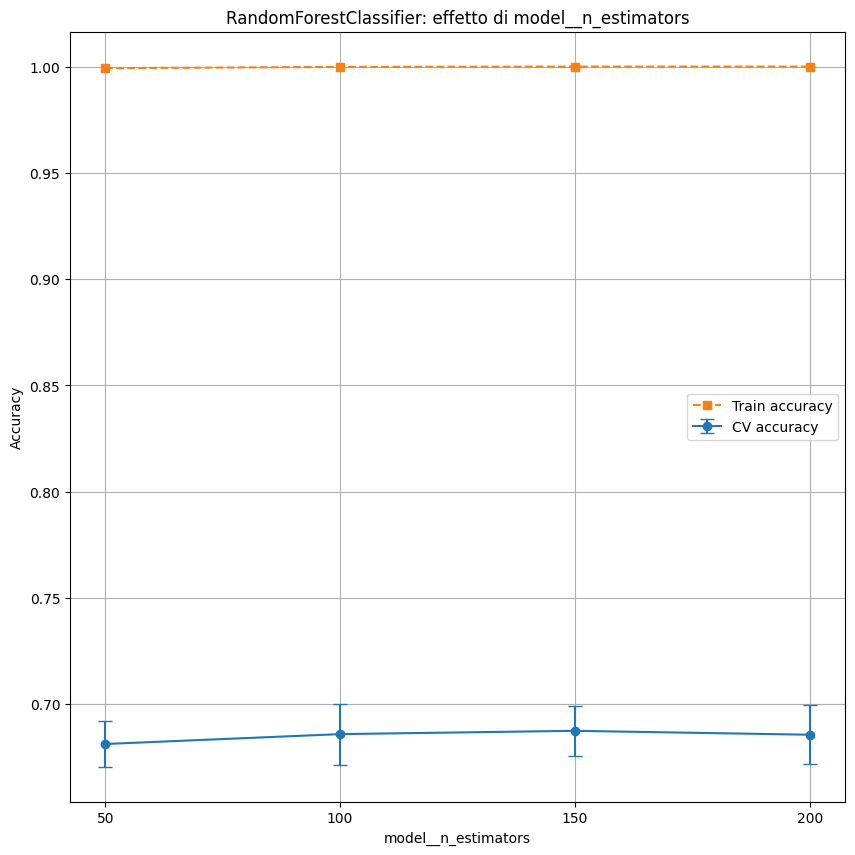

In [43]:
forest_results = forest_grid.cv_results_

depths = forest_param_grid["model__n_estimators"]
depth_labels = [str(d) for d in depths]

means_test = []
means_train = []
stds = []

for depth in depths:
    for p, mean_test, mean_train, std in zip(
        forest_results["params"],
        forest_results["mean_test_score"],
        forest_results["mean_train_score"],
        forest_results["std_test_score"],
    ):
        if p["model__n_estimators"] == depth and p["model__max_depth"] == 20 and p["model__min_samples_leaf"] == 1:
            means_test.append(mean_test)
            means_train.append(mean_train)
            stds.append(std)
            break

plt.figure(figsize=(10, 10))
plt.errorbar(depth_labels, means_test, yerr=stds, marker="o", capsize=5, label="CV accuracy")
plt.plot(depth_labels, means_train, marker="s", linestyle="--", label="Train accuracy")
plt.xlabel("model__n_estimators")
plt.ylabel("Accuracy")
plt.title("RandomForestClassifier: effetto di model__n_estimators")
plt.legend()
plt.grid(True)
plt.show()

La CV Accuracy cresce leggermente con 50 alberi fino a stabilizzarsi intorno a 150, dove raggiunge il valore ottimale. Aggiungere ulteriori alberi oltre 150 non porta miglioramenti significativi.   
La Train Accuracy a 1.0 indica che ogni singolo albero memorizza perfettamente i dati di training, ma generalizza male. Combinando il voto di 150 alberi, gli errori dei singoli tendono a cancellarsi e la CV Accuracy si stabilizza ad un valore molto alto rispetto a quello del singolo albero decisionale.

Il Random Forest supera il singolo albero decisionale grazie al meccanismo di ensemble: combinando i risultati di molti alberi addestrati su sottocampioni diversi, le predizioni si compensano riducendo la varianza e migliorando la generalizzazione.

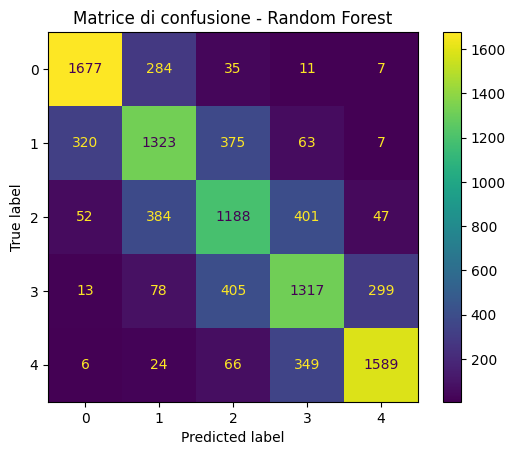

Accuracy: 0.6874031007751938


In [44]:
# Confusion matrix per valutare le prestazioni del modello 
y_pred = cross_val_predict(forest_grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)
disp.plot()
plt.title("Matrice di confusione - Random Forest")
plt.show()

# Accuracy calcolata per il multiclasse 
print("Accuracy:", accuracy_score(y, y_pred))

Il Random Forest ottiene un'accuracy di 0.68 in cross-validation, la migliore tra tutti i modelli testati e il pattern degli errori rimane lo stesso.

## 10. Conclusioni
Dopo aver analizzato ogni Modello, scegliamo quello migliore

In [45]:
print("RidgeClassifier")
print("best params:", ridge_grid.best_params_)
print("best CV accuracy:", ridge_grid.best_score_)

print("\nLogisticRegression")
print("best params:", logistic_grid.best_params_)
print("best CV accuracy:", logistic_grid.best_score_)

print("\nkNNeighborsClassifer")
print("best params:", knn_grid.best_params_)
print("best CV accuracy:", knn_grid.best_score_)

print("\nDecisionTreeClassifier")
print("best params:", tree_grid.best_params_)
print("best CV accuracy:", tree_grid.best_score_)

print("\nRandomForestClassifier")
print("best params:", forest_grid.best_params_)
print("best CV accuracy:", forest_grid.best_score_)

model_names = ["RidgeClassifier", "LogisticRegression", "kNNeighborsClassifer", "DecisionTree", "RandomForestClassifier"]
best_cv_scores = [ridge_grid.best_score_, logistic_grid.best_score_, knn_grid.best_score_, tree_grid.best_score_, forest_grid.best_score_]

RidgeClassifier
best params: {'model__estimator__alpha': 0.1}
best CV accuracy: 0.4919573643410852

LogisticRegression
best params: {'model__C': 1000.0}
best CV accuracy: 0.5645348837209303

kNNeighborsClassifer
best params: {'model__n_neighbors': 20}
best CV accuracy: 0.5708333333333334

DecisionTreeClassifier
best params: {'model__max_depth': 15, 'model__min_samples_leaf': 10}
best CV accuracy: 0.6038759689922479

RandomForestClassifier
best params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 150}
best CV accuracy: 0.6874031007751938


In [46]:
best_index = best_cv_scores.index(max(best_cv_scores))
final_model_name = model_names[best_index]
final_model = [ridge_grid, logistic_grid, knn_grid, tree_grid, forest_grid][best_index].best_estimator_

print("Modello finale scelto:", final_model_name)

Modello finale scelto: RandomForestClassifier


Classifica dal modello migliore al modello peggiore in base al CV Accuracy:
1. Random Forest
2. Decision Tree
3. kNN
4. Logistic Regression
5. Ridge Classifier

I modelli lineari (Ridge e Logistic) ottengono le prestazioni peggiori, suggerendo che il problema ha una struttura non lineare che i modelli lineari non riescono a catturare. 
I metodi non lineari (kNN, albero e Random Forest) performano tutti meglio.

In tutti i modelli il pattern degli errori è coerente con la natura ordinale del target: gli errori si concentrano tra classi adiacenti, mentre le classi estreme 0 e 4 vengono sempre riconosciute meglio.  
Le feature più importanti risultano median_income e distance_to_coast, confermando l'analisi delle correlazioni della sezione 2.